<a href="https://colab.research.google.com/github/alexanderson522/INFO648/blob/main/FinalProject/INFO648_Final_Project_AA_JK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INFO 648 - Final Project
Alex Anderson, Jared Kline

#Part 1 - Business Understanding
We are data scientists at the Dept of Economic Development. We want to predict future neighborhood growth so we can properly allocate funding to growing areas. In order to properly allocate funding to growing population centers, we first have to identify which areas will actually grow.

<br>

**Target Definition:**

We will compute the growth percentage as follows:
$$ \text{growth_pct} = \frac{{pop_{2020}} - {pop_{2010}}}{{pop_{2010}}} \times 100 $$

Using `growth_pct`, we will populate our binary variable `growth`:

`growth=1` if `growth_pct>0`

`growth=o` if `growth_pct>0`

<br>

**Success Criterion:**
We will consider our model a success if our classifier beats the majority-class baseline by **0.1** on AUC (e.g. AUC >= **0.6**)

In [37]:
#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.cluster import KMeans

#Part 2 - Data Understanding

Observe the overall data before diving in. Our assigned division is the Mid Atlantic, which is made up of New Jersey, New York, and Pennsylvania.

In [30]:
#read in raw data
raw_data = pd.read_csv('/content/student_tracts_raw.csv')
raw_data.shape
#~73k rows

(73057, 49)

In [31]:
#drop na rows
new_data = raw_data.dropna().copy()
new_data.shape
#dropped ~300 rows

(72739, 49)

In [32]:
#create initial growth_pct field and growth target field
new_data["growth_pct"] = (new_data["pop_total_2020"] - new_data["pop_total_2010"]) / new_data["pop_total_2010"] * 100
new_data["growth"] = (new_data["growth_pct"] > 0).astype(int)

In [33]:
#initial Class Balance
class_balance = new_data["growth"].value_counts(normalize=True).sort_index()
print("Class balance (0 = lost/no gain, 1 = grew):")
print(class_balance)

Class balance (0 = lost/no gain, 1 = grew):
growth
0    0.364454
1    0.635546
Name: proportion, dtype: float64


Our nation-wide class balance shows that 63.6% of all tracts in the dataset have experienced growth from 2010 to 2020

In [35]:
#check which states have the highest and lowest percentage of growing tracts
state_growth_percentage = new_data.groupby('STATE')['growth'].mean() * 100

print("Top 10 States by % of Tracts with Growth:")
print(state_growth_percentage.nlargest(10))
print("\nBottom 10 States by % of Tracts with Growth:")
print(state_growth_percentage.nsmallest(10))

Top 10 States by % of Tracts with Growth:
STATE
Washington              93.914246
Oregon                  91.535671
District Of Columbia    89.385475
Massachusetts           86.335826
Idaho                   86.241611
Colorado                83.026421
Rhode Island            80.912863
Florida                 80.376280
Utah                    79.931973
New Hampshire           78.911565
Name: growth, dtype: float64

Bottom 10 States by % of Tracts with Growth:
STATE
West Virginia    25.000000
Mississippi      36.611195
Illinois         42.774752
Kansas           44.675325
Louisiana        44.718310
Arkansas         45.626822
Iowa             45.696970
Wyoming          46.212121
New Mexico       46.292585
Ohio             47.759674
Name: growth, dtype: float64


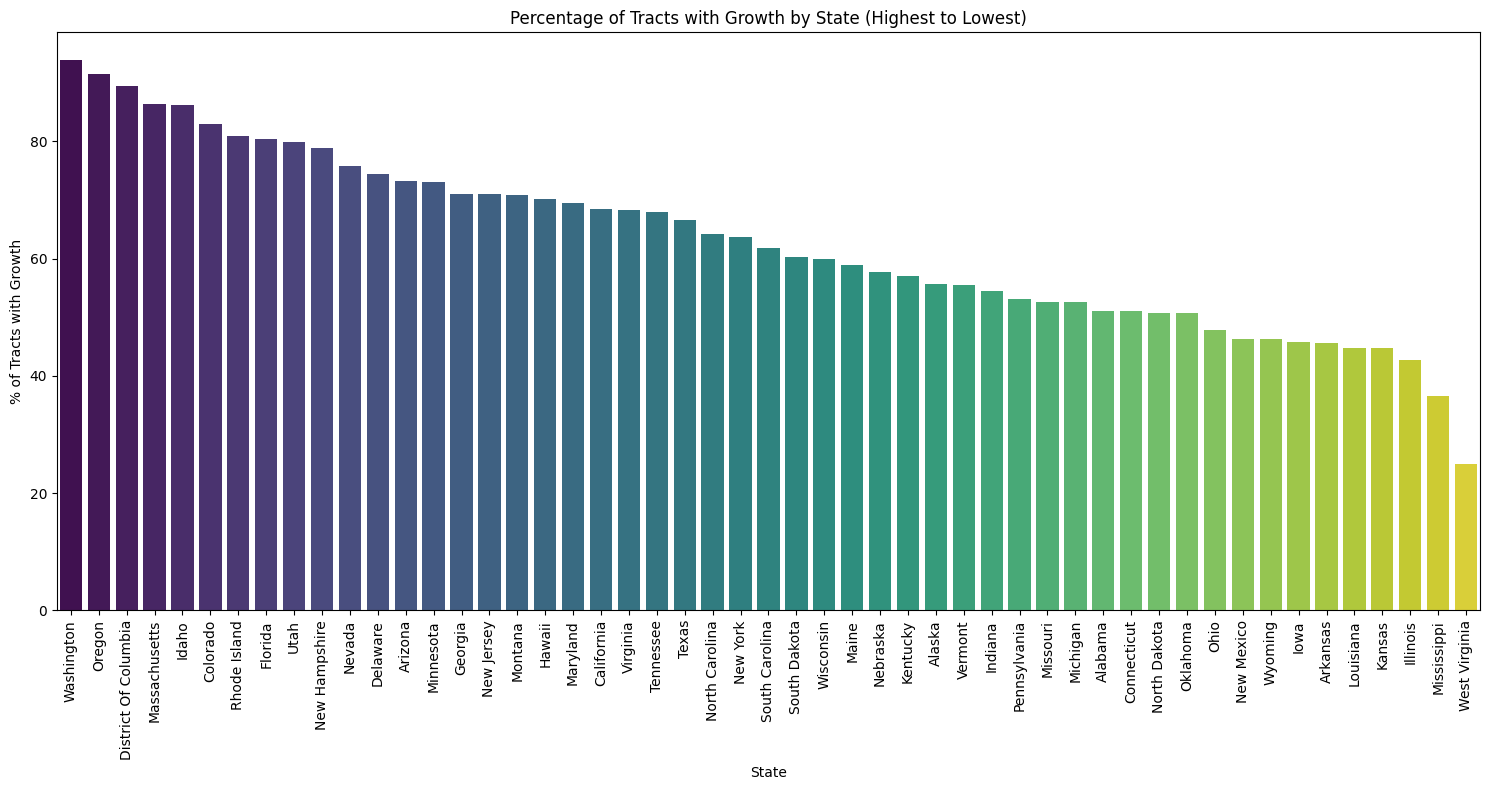

In [41]:
plt.figure(figsize=(15, 8))
sorted_state_growth_percentage = state_growth_percentage.sort_values(ascending=False)
sns.barplot(x=sorted_state_growth_percentage.index, y=sorted_state_growth_percentage.values, hue=sorted_state_growth_percentage.index, palette='viridis', legend=False)
plt.title('Percentage of Tracts with Growth by State (Highest to Lowest)')
plt.xlabel('State')
plt.ylabel('% of Tracts with Growth')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

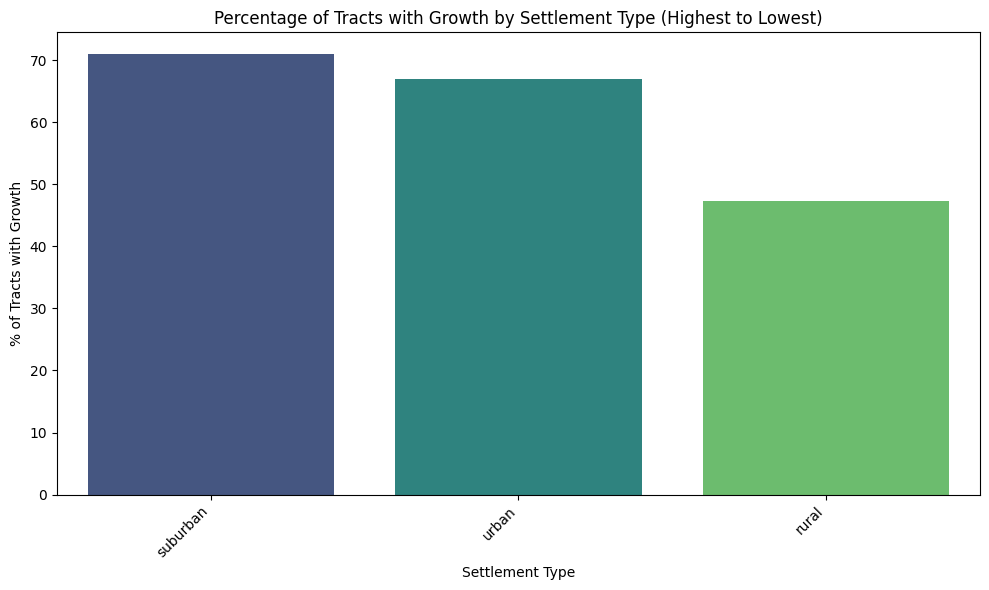

In [43]:
# check % of tracts with growth broken down by settlement type
settlement_growth_percentage = new_data.groupby('settlement_type')['growth'].mean() * 100

plt.figure(figsize=(10, 6))
sorted_settlement_growth_percentage = settlement_growth_percentage.sort_values(ascending=False)
sns.barplot(x=sorted_settlement_growth_percentage.index, y=sorted_settlement_growth_percentage.values, hue=sorted_settlement_growth_percentage.index, palette='viridis', legend=False)
plt.title('Percentage of Tracts with Growth by Settlement Type (Highest to Lowest)')
plt.xlabel('Settlement Type')
plt.ylabel('% of Tracts with Growth')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
#check for tracts with no population
(new_data["pop_total_2010"] == 0).sum()
#208 tracts with no population

np.int64(208)

In [25]:
#check for tracts with no land area
(new_data["land_area_sqkm"] == 0).sum()
#0 tracts with no land

np.int64(0)

In [6]:
new_data.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
0,G0100010020100,Alabama,1,Autauga County,1,20100,1912,693,59,536,...,21,0,1,0,13,9,1775.0,9.809944,194.904273,suburban
1,G0100010020200,Alabama,1,Autauga County,1,20200,2170,743,79,469,...,44,3,0,0,24,4,2055.0,3.340505,649.602380,suburban
2,G0100010020300,Alabama,1,Autauga County,1,20300,3373,1256,70,949,...,38,0,2,0,28,19,3216.0,5.349274,630.552856,suburban
3,G0100010020400,Alabama,1,Autauga County,1,20400,4386,1722,101,1357,...,56,2,0,1,21,5,4246.0,6.382705,687.169468,suburban
4,G0100010020500,Alabama,1,Autauga County,1,20500,10766,4082,226,2459,...,228,19,4,4,78,22,11222.0,11.397725,944.574466,suburban


In [14]:
#filter for mid atalantic states
mid_atlantic_states = ['New Jersey', 'New York', 'Pennsylvania']
Mid_atl_data = new_data[new_data['STATE'].isin(mid_atlantic_states)].copy()

#show unique states in df
Mid_atl_data['STATE'].unique()

array(['New Jersey', 'New York', 'Pennsylvania'], dtype=object)

In [12]:
Mid_atl_data.shape
#leaves us with 10k rows

(10121, 49)

In [15]:
Mid_atl_data.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
40686,G3400010000100,New Jersey,34,Atlantic County,1,100,2417,857,79,361,...,466,89,9,5,371,56,2334.0,1.688765,1431.223409,urban
40687,G3400010000200,New Jersey,34,Atlantic County,1,200,3202,1275,654,674,...,390,46,7,2,514,52,2897.0,0.523330,6118.510309,urban
40688,G3400010000300,New Jersey,34,Atlantic County,1,300,4373,1411,288,376,...,730,99,19,4,1056,367,4027.0,0.359772,12154.920338,urban
40689,G3400010000400,New Jersey,34,Atlantic County,1,400,2606,1186,1116,388,...,258,35,6,1,511,64,3243.0,0.676905,3849.875536,urban
40690,G3400010000500,New Jersey,34,Atlantic County,1,500,3503,929,135,371,...,382,52,26,3,1002,238,3012.0,0.267914,13075.091261,urban


In [19]:
df = Mid_atl_data.copy()#create a more manageable df name for coding

In [26]:
#check for tracts with no population
(df["pop_total_2010"] == 0).sum()
#39 mid atlantic tracts with no population

np.int64(39)

In [27]:
#check for tracts with no land area
(df["land_area_sqkm"] == 0).sum()
#0 mid atlantic tracts with no land

np.int64(0)

In [ ]:

MIN_POP_CUTOFF = 50

before = len(df)
df = df[df["pop_total_2010"] >= MIN_POP_CUTOFF].copy()
print(f"Dropped {before - len(df)} tracts under the {MIN_POP_CUTOFF}-person minimum-population cutoff.")
print(f"Remaining: {len(df):,}")